In [1]:
import numpy as np
from scipy.io import loadmat
#In this case, I took the trouble of saving it out to an old matlab 
#format that scipy uses. 
#if you have data in matlab files, pip install hdf5storage and use their 
#version of loadmat which works with matlab's new hdf5 format, and can 
# be written to flexibly preserve python and matlab structures. 
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA 

In [2]:
#%% LOAD THE MAT FILE THAT HAS THE FACES 
f = loadmat('../data/faces.mat')
faces = f['faces'] #This are the faces.  There are 72 faces closely cropped to the boundary of the face.
smiling = f['smiling'][0] #Flag to indicate if the face was a smile. 0 means neutral expression and 1 means smiling.
#%% PCA 


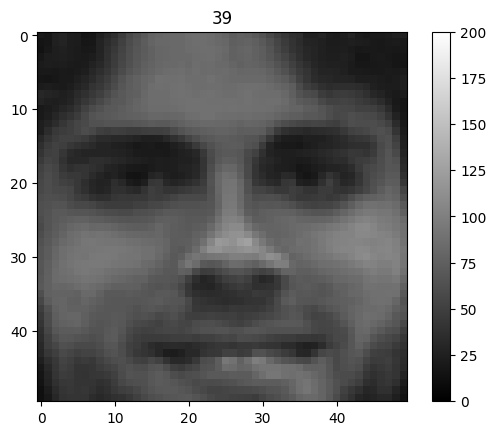

In [3]:
imageno  = 39
f1 = faces[imageno,:,:]
plt.figure()
plt.imshow(f1,cmap='gray',vmin = 0,vmax = 200)
plt.title(imageno)
plt.colorbar()
#plt.axis('off')

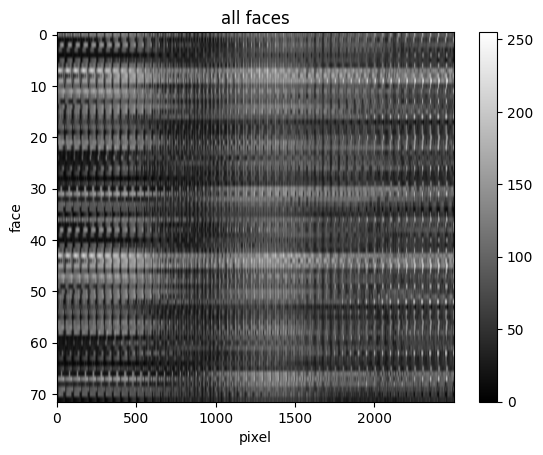

In [4]:
faces_data = faces.reshape(72,50*50)
plt.figure()
plt.imshow(faces_data,cmap='gray',vmin = 0,vmax = 255,aspect = "auto")
plt.title("all faces")
plt.xlabel("pixel")
plt.ylabel("face")
plt.colorbar()
plt.show()

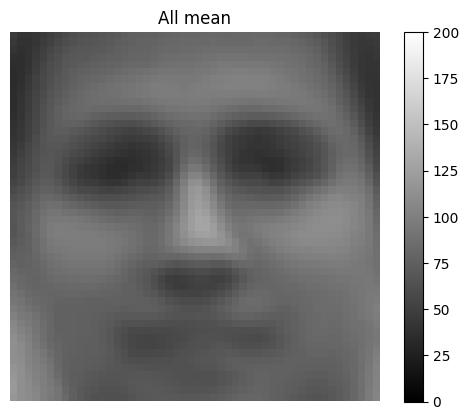

In [5]:
allmean = np.mean(faces,axis = 0)
plt.figure()
plt.imshow(allmean,cmap='gray',vmin = 0,vmax = 200)
plt.title("All mean")
plt.colorbar()
plt.axis("off")
plt.show()

In [ ]:
pca = PCA(n_components = 71) #decide of number of components. ALWAYS smaller than the number of observations, how many eigenvectors you want to estimate
                             #if you dont specify it, it will give you min(nsamples,nfeatures)-1
pca.fit(faces_data) #fit the model
eigenvector = pca.components_ #get the eigenvectors - components
latent = pca.explained_variance_ #get the eigenvalues - 
#normalized as explained variance
score = pca.transform(faces_data) # get the score, 
#"coordinate" of each face in the new pc coordinate system 
#%%

* All latent variable analyses begin by examining how much variance is expressed by each latent variable.  

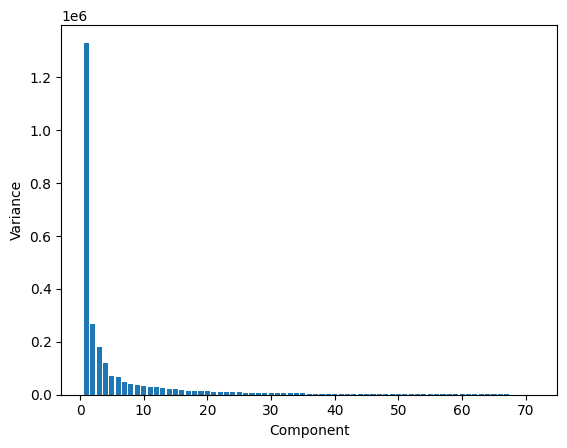

In [7]:
#ALWAYS PLOT LATENT FIRST
plt.figure()
plt.bar(range(1,72),latent)
plt.xlabel('Component')
plt.ylabel("Variance")
plt.show()



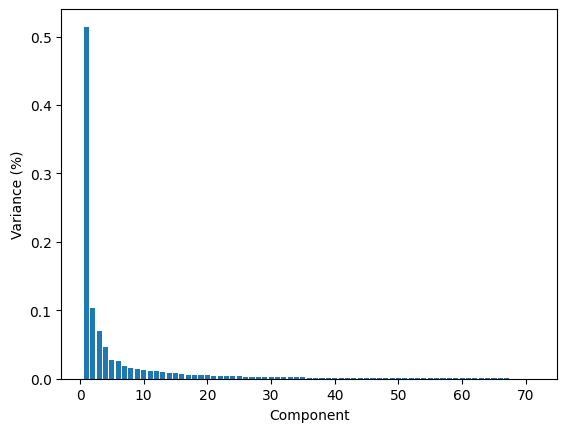

In [8]:
#Its more useful to express variance as a fraction of total. 
prct_latent = pca.explained_variance_ratio_
plt.figure()
plt.bar(range(1,72),prct_latent)
plt.xlabel('Component')
plt.ylabel("Variance (%)")
plt.show()

* This is pretty interesting. The first principal component accounts for more than half the variance in the data.  
* It quickly falls off, and by the 20th component, hardly any variability is left. 

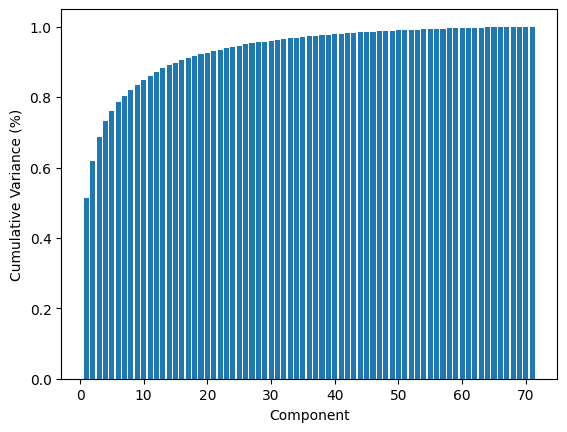

In [9]:
cum_latent = np.cumsum(prct_latent)
plt.figure()
plt.bar(range(1,72),cum_latent)
plt.xlabel('Component')
plt.ylabel("Cumulative Variance (%)")
plt.show()

* Like all good data analysis methods, PCA removes the mean of the data. You can get it back from the PCA object and it should look familiar to you. 
* When you apply it to data **where all the data are in the same units**, its fine to do it the way I did it. 
* If you are using data in different units, always use `StandardScaler` to put all the data in standardized units. 

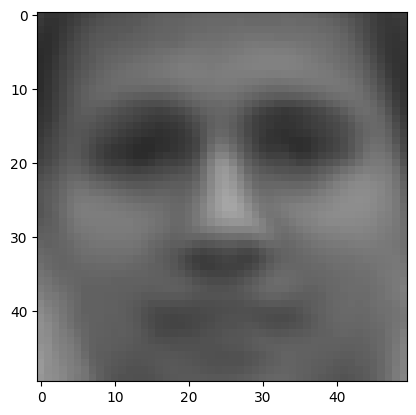

In [10]:
meanface = pca.mean_
mf = meanface.reshape(50,50)
plt.imshow(mf,cmap="gray",vmin = 0, vmax = 200)
plt.show()

* Visualize Eigenvectors

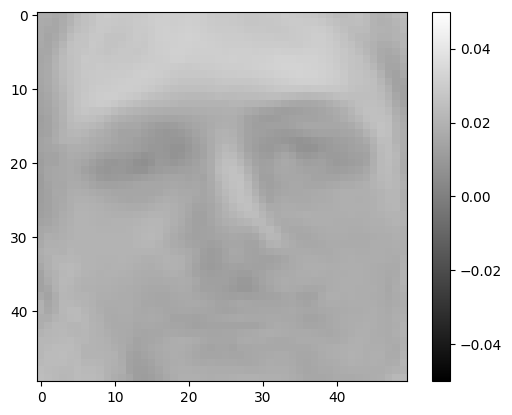

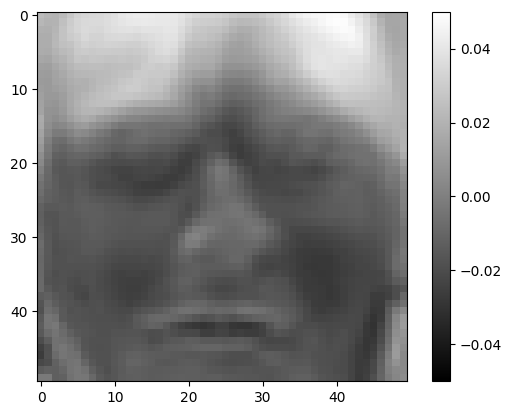

In [11]:
eigenfaces = eigenvector.reshape(71,50,50)
for j in range(2):
    plt.figure()
    plt.imshow(eigenfaces[j,:,:],cmap = 'gray',vmin = -0.05, vmax = 0.05)
    plt.colorbar()
    plt.show()


* Interpreting the Scores -> The coordinate of each face ("Loading") in the coordinate system defined by the eigenvectors

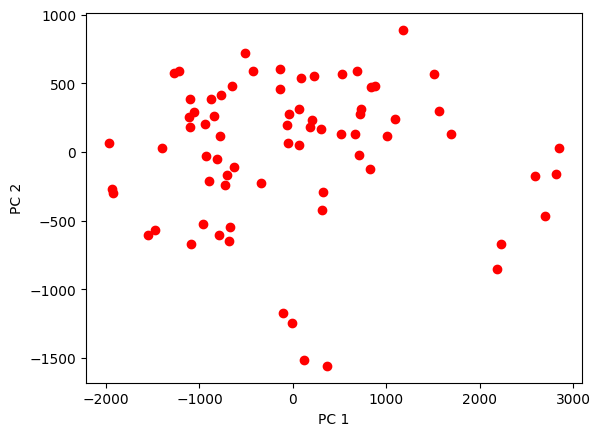

In [12]:
plt.figure()
plt.plot(score[:,0],score[:,1],'ro')
plt.xlabel('PC 1')
plt.ylabel('PC 2')
plt.show()

* Any face can be approximated using the eigenfaces and the weights given by the score. 

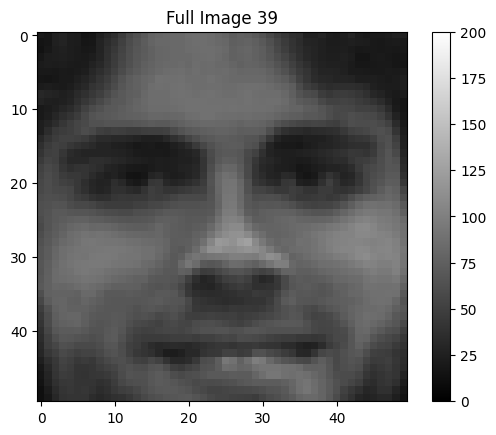

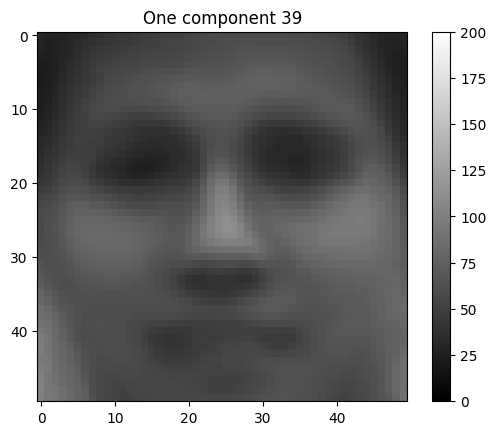

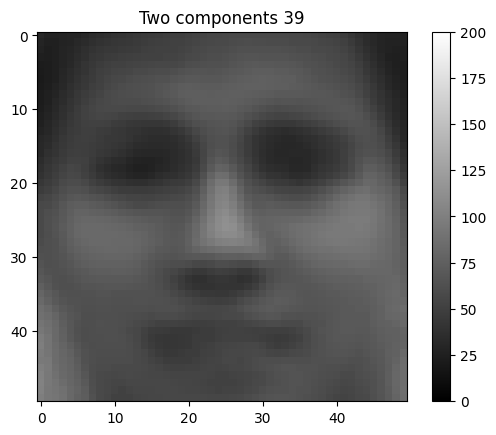

In [13]:
imageno  = 39
f1 = faces[imageno,:,:]
plt.figure()
plt.imshow(f1,cmap='gray',vmin = 0,vmax = 200)
plt.title("Full Image " + str(imageno))
plt.colorbar()
proj1 = score[imageno,0]*eigenvector[0,:]
makeface1 = proj1.reshape(50,50)+meanface.reshape(50,50)
plt.figure()
plt.imshow(makeface1,cmap='gray',vmin = 0,vmax = 200)
plt.title("One component " + str(imageno))
plt.colorbar()
makeface2 = score[imageno,0]*eigenvector[0,:]+score[imageno,1]*eigenvector[1,:]
makeface2 = makeface2.reshape(50,50)+meanface.reshape(50,50)

plt.figure()
plt.imshow(makeface2,cmap='gray',vmin = 0,vmax = 200)
plt.title("Two components " + str(imageno))
plt.colorbar()

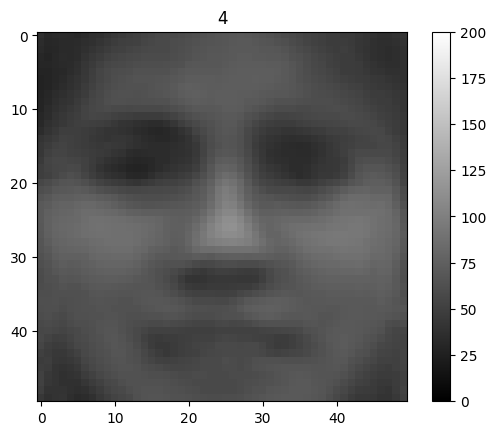

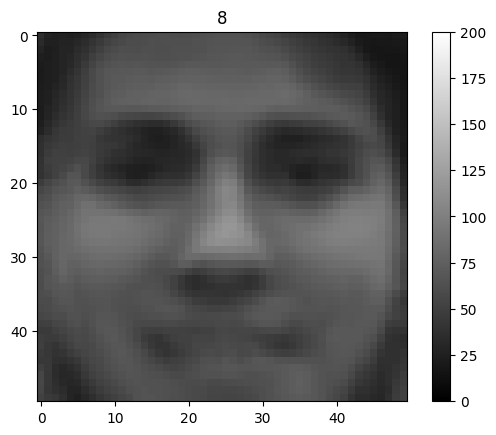

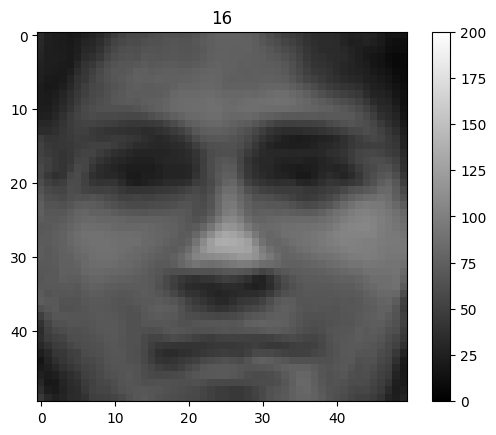

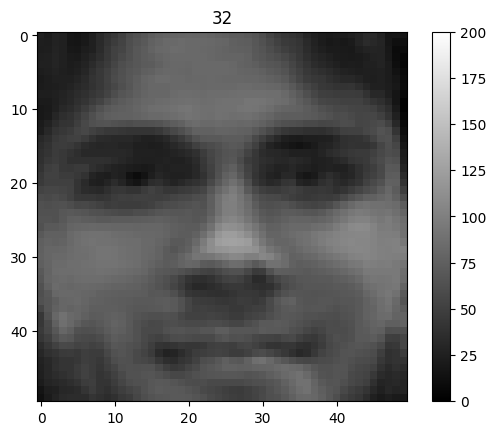

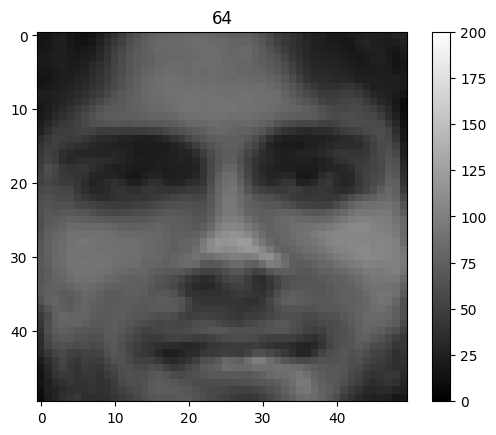

In [14]:
ncomp = [4,8,16,32,64]
for j in ncomp:
    compface = score[imageno,np.arange(j)]@eigenvector[np.arange(j),:]+meanface
    makeface = compface.reshape(50,50)
    plt.figure()
    plt.imshow(makeface,cmap='gray',vmin = 0,vmax = 200)
    plt.title(j)
    plt.colorbar()


Why is the number of principal components the mininum of the rows and columns (less 1)?

Hint: there is nothing special about features (columns) and samples(rows)

If time permits:

Lets look at this through the lens of a singular value decomposition

$$ A = USV^T $$

In [15]:
meanface = np.mean(faces_data,axis = 0)
for j in range(72): 
    faces_data[j,:] = faces_data[j,:] - meanface


In [16]:
u,s,v = np.linalg.svd(faces_data,full_matrices=True)
print(u.shape)
print(s.shape)
print(v.shape)
print(s[0])
print(s[-1])

(72, 72)
(72,)
(2500, 2500)
9719.956948931782
8.30874240966223e-12


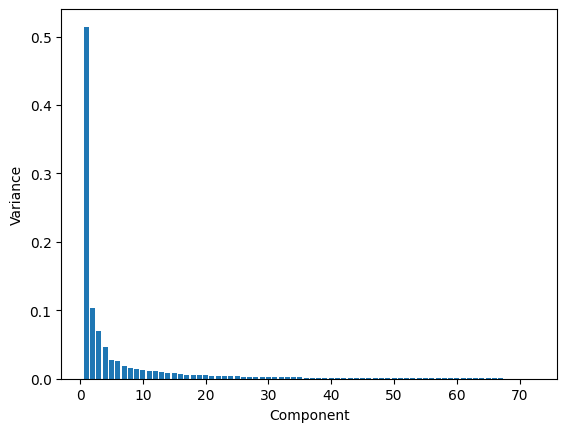

In [17]:
plt.figure()
plt.bar(range(1,73),s**2/sum(s**2))
plt.xlabel('Component')
plt.ylabel("Variance")
plt.show()

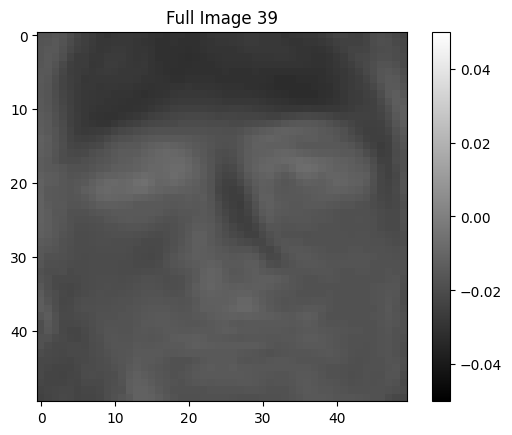

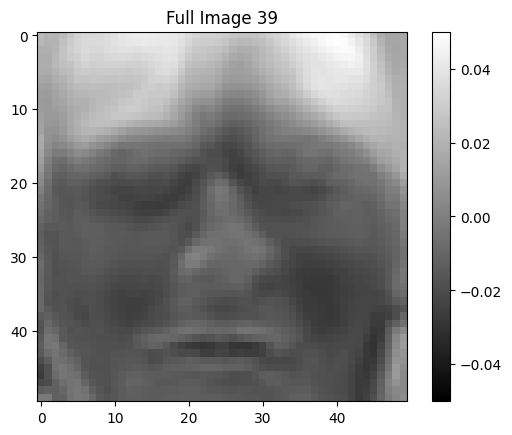

In [18]:

plt.figure()
plt.imshow(v[0,:].reshape(50,50),cmap='gray', vmin = -0.05, vmax = 0.05)
plt.title("Full Image " + str(imageno))
plt.colorbar()
plt.figure()
plt.imshow(v[1,:].reshape(50,50),cmap='gray',vmin = -0.05, vmax =0.05)
plt.title("Full Image " + str(imageno))
plt.colorbar()

In [19]:
x = np.dot(v[0,:],v[1,:])
print(x)

3.421742056364252e-16


In [20]:
y = np.dot(u[:,0],u[:,1])
print(y)

-3.0152592146725706e-16


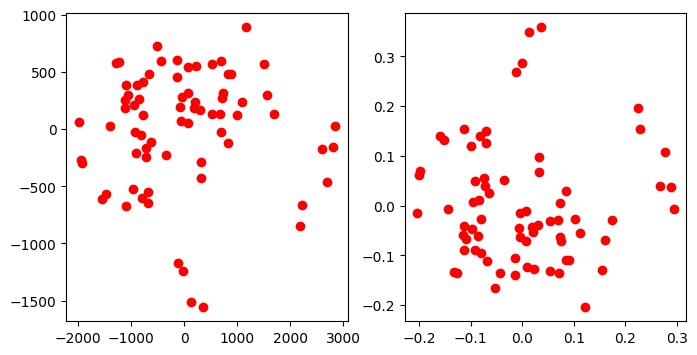

In [21]:
fig, ax = plt.subplots(1,2,figsize = (8,4))
ax[0].plot(score[:,0],score[:,1],'ro')
ax[1].plot(-u[:,0],-u[:,1],'ro')
